# Trustworthy Backtest Framework — Strategy vs Benchmark (実データ)

**EN.** This notebook runs the moving-average-cross strategy on real market data and compares it *honestly* against a buy-&-hold benchmark. The point of the project is not that the strategy wins — it is that the backtest can be trusted. Where the strategy loses, we say so.

**JA.** 本ノートブックは移動平均クロス戦略を実データで実行し、バイ＆ホールドとフェアに比較します。本プロジェクトの目的は「戦略が勝つこと」ではなく「バックテストが信用できること」です。負けている場合も正直に示します。

> All look-ahead protection lives in the engine (`target_position.shift(EXECUTION_LAG)`); see `src/backtest/engine.py`.
> ルックアヘッド対策はエンジン側に集約されています。

In [1]:
import sys, pathlib
# Make the repository root importable when running from notebooks/.
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.backtest.engine import run_backtest, BacktestConfig, assert_causal
from src.backtest.strategies import MovingAverageCrossStrategy
from src.backtest import metrics
from src.backtest.data import load_prices, DataError

## 1. Load data / データ取得

**EN.** We fetch split/dividend-adjusted SPY closes. If the machine is offline, we fall back to a *clearly labelled* synthetic geometric Brownian motion path so the notebook always runs — but the synthetic path is never presented as a real result.

**JA.** 分割・配当調整済みの SPY 終値を取得します。オフライン環境では明示ラベル付きの合成 GBM 系列にフォールバックし、常に実行可能にします（合成データを実結果として提示することはありません）。

In [2]:
TICKER = "SPY"
START, END = "2010-01-01", "2023-12-31"

try:
    prices = load_prices(TICKER, START, END)
    DATA_SOURCE = f'real ({TICKER}, yfinance)'
except Exception as exc:  # offline / rate-limited -> synthetic fallback
    print(f'Live download failed ({exc!r}); using SYNTHETIC fallback.')
    rng = np.random.default_rng(0)
    idx = pd.date_range(START, END, freq='B')
    daily = rng.normal(0.0003, 0.011, len(idx))  # ~7.5%/yr, ~17% vol
    prices = pd.Series(100 * np.exp(np.cumsum(daily)), index=idx, name=TICKER)
    DATA_SOURCE = 'SYNTHETIC (offline fallback — not a real result)'

print('Data source:', DATA_SOURCE)
print('Observations:', len(prices))
prices.tail()

Data source: real (SPY, yfinance)
Observations: 3522


Date
2023-12-22    460.964386
2023-12-26    462.910858
2023-12-27    463.747864
2023-12-28    463.922974
2023-12-29    462.579926
Name: SPY, dtype: float64

## 2. Causality check / 因果性チェック

**EN.** Before trusting any P&L, we *prove* the strategy has no look-ahead bias on this very data: perturbing future prices must not change past signals. If this raises, nothing below is trustworthy.

**JA.** P&L を信じる前に、この実データ上で戦略にルックアヘッドが無いことを証明します（未来を改変しても過去のシグナルが変わらない）。

In [3]:
strategy = MovingAverageCrossStrategy(fast_window=50, slow_window=200)
assert_causal(strategy, prices, n_trials=10)
print(f'{strategy.name}: causality check PASSED — no look-ahead bias.')

MA(50,200): causality check PASSED — no look-ahead bias.


## 3. Run the backtest / バックテスト実行

**EN.** Long/short 50/200 MA cross with realistic frictions (5 bps commission + 5 bps slippage per unit turnover), versus a fully invested buy-&-hold of the same asset.

**JA.** 現実的なコスト（往復前の片道 5bps 手数料 + 5bps スリッページ）を課した 50/200 MA クロスを、同一資産のバイ＆ホールドと比較します。

In [4]:
RISK_FREE = 0.02  # 2%/yr, used for Sharpe
config = BacktestConfig(commission=0.0005, slippage=0.0005)

result = run_backtest(prices, strategy, config)

# Benchmark: always-long buy & hold of the same series, same engine,
# so the look-ahead lag and return convention are identical.
class BuyAndHold:
    name = 'Buy & Hold'
    def generate_signals(self, p):
        return pd.Series(1.0, index=p.index)

benchmark = run_backtest(prices, BuyAndHold(), BacktestConfig())
result.equity_curve.tail()

Date
2023-12-22    1.624050
2023-12-26    1.630908
2023-12-27    1.633857
2023-12-28    1.634474
2023-12-29    1.629742
dtype: float64

## 4. Equity curves / 資産曲線

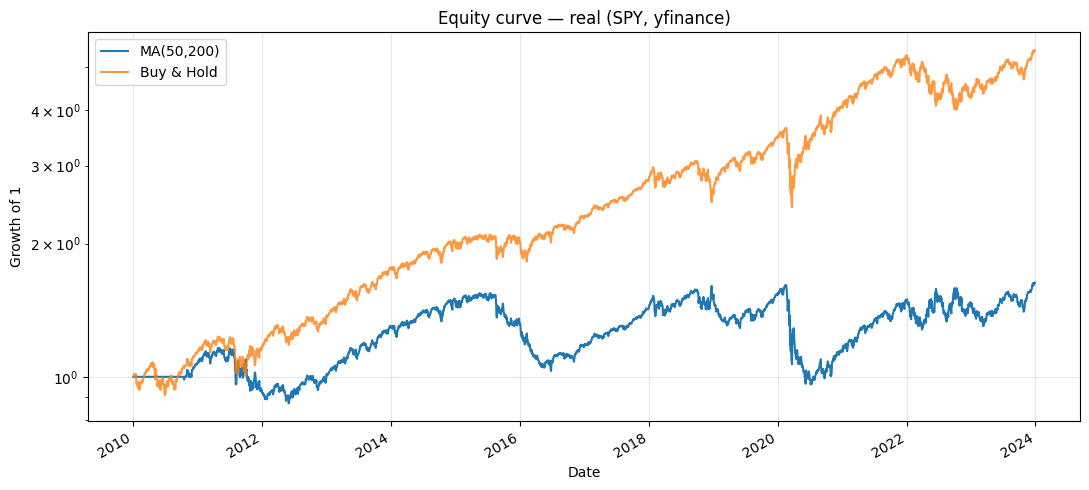

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
result.equity_curve.plot(ax=ax, label=strategy.name, lw=1.5)
benchmark.equity_curve.plot(ax=ax, label='Buy & Hold', lw=1.5, alpha=0.8)
ax.set_title(f'Equity curve — {DATA_SOURCE}')
ax.set_ylabel('Growth of 1')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Drawdown curves / ドローダウン曲線

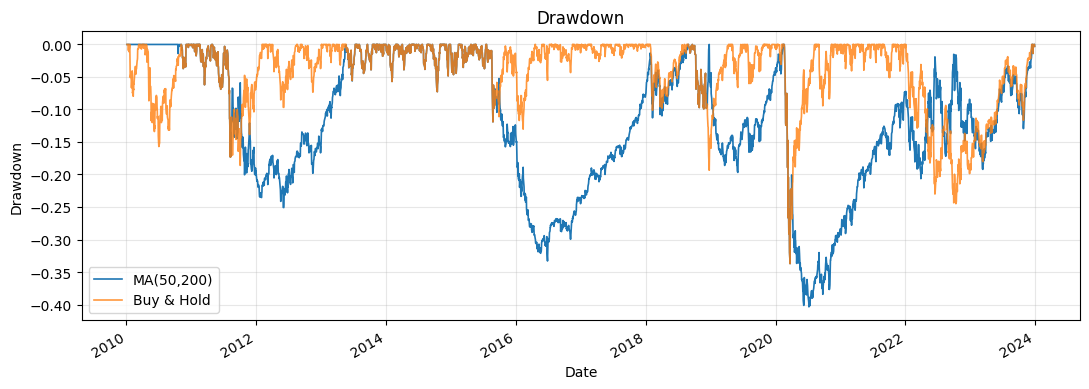

In [6]:
def drawdown_series(returns):
    wealth = (1 + returns).cumprod()
    return wealth / wealth.cummax() - 1.0

fig, ax = plt.subplots(figsize=(11, 4))
drawdown_series(result.returns).plot(ax=ax, label=strategy.name, lw=1.2)
drawdown_series(benchmark.returns).plot(ax=ax, label='Buy & Hold', lw=1.2, alpha=0.8)
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Metrics summary / 指標サマリー

In [7]:
table = pd.DataFrame({
    strategy.name: metrics.summary(result.returns, RISK_FREE),
    'Buy & Hold': metrics.summary(benchmark.returns, RISK_FREE),
})
# Present percentages where natural. Build an object-dtype table so the
# formatted strings coexist with no float-dtype coercion (pandas 3.0).
pct_rows = {'annualized_return', 'annualized_volatility', 'max_drawdown'}
display_table = table.astype(object)
for r in table.index:
    if r in pct_rows:
        display_table.loc[r] = table.loc[r].map(lambda x: f'{x * 100:,.2f}%')
    else:
        display_table.loc[r] = table.loc[r].map(lambda x: f'{x:,.3f}')
display_table

,"MA(50,200)",Buy & Hold
annualized_return,3.56%,12.91%
annualized_volatility,16.73%,17.33%
sharpe_ratio,0.173,0.672
max_drawdown,-40.36%,-33.72%
max_drawdown_duration,96.000,23.000
win_rate,0.541,0.552
profit_loss_ratio,0.898,0.941


## 7. Honest verdict / 正直な結論

**EN.** Read the table above first. On this SPY sample the long/short 50/200 MA cross **lost on every metric** — lower return, lower Sharpe, *and a larger* maximum drawdown than simply buying and holding. Why: in a market that trends up for most of the period, the **short leg gets run over**, and the slow cross **whipsaws** around flat patches while paying costs on every turn. A long-only variant would avoid the worst of the short-leg damage, but the headline lesson stands: a plausible, textbook rule can comfortably **underperform a passive benchmark**. We show that result rather than hide it — that is the entire point of the project.

**JA.** まず上の表を確認してください。この SPY 期間では、ロング/ショート型の 50/200 MA クロスは**全指標でバイ＆ホールドに負けました**——リターンもシャープも低く、**最大ドローダウンはむしろ大きい**結果です。理由は、長期上昇相場では**ショート側が踏み上げられ**、横ばい局面で**ダマシ（whipsaw）**を繰り返しながら毎回コストを払うためです。ロングオンリーにすればショート側の損失は緩和できますが、教訓は変わりません——教科書的でもっともらしいルールが、パッシブなベンチマークに平然と負け得るということです。それを隠さず示すことこそ本プロジェクトの目的です。

> The value here is methodological: a trustworthy harness, not a magic strategy. 価値は手法の信頼性にあり、魔法の戦略ではありません。